## Import Necessary Libraries

In [2]:
import numpy as np
import pandas as pd 
import sklearn.preprocessing as pp
import matplotlib.pyplot as plt 
import sklearn.model_selection as ms 
import seaborn as sns 
#-----------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix 
from sklearn.preprocessing import MinMaxScaler
#---------------------------------------
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
#---------------------------------------
import torch
from torch import nn, optim

## Reading The Dataset 

In [2]:
df_path = 'C:\\AI - Field\\Ds_Bootcamp\\Ds_4thweek\\mnist_with_anomalies.csv'
df = pd.read_csv(df_path)
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Pre-Processing 

In [3]:
# Checking for Null Values in Datset 

df.isnull().sum()

# Checking for Duplicated Values in Dataset

df.duplicated().sum()
df = df.drop_duplicates()
df.shape

# Train / Validation Split 
X = df
X_train,X_temp = train_test_split(X, test_size=0.25, random_state=42)
X_val,X_test =  train_test_split(X_temp, test_size=0.5, random_state=42)


# Feature Scaling With MinMaxScaler

scaler = MinMaxScaler()

scaled_Train_df = scaler.fit_transform(X_train)
scaled_Train_df = pd.DataFrame(scaled_Train_df, columns=X_train.columns)

scaled_Val_df = scaler.transform(X_val)
scaled_Val_df = pd.DataFrame(scaled_Val_df, columns=X_val.columns)

scaled_Test_df = scaler.transform(X_test)
scaled_Test_df = pd.DataFrame(scaled_Test_df, columns=X_test.columns)


## PCA / Feature Engineering


In [4]:
# PCA For Dimentionality Reduction

pca = PCA(n_components = 2)

pca_Train = pca.fit_transform(scaled_Train_df)
pca_Train = pd.DataFrame(pca_Train, columns=['PC1','PC2'])

pca_Val = pca.transform(scaled_Val_df)
pca_Val = pd.DataFrame(pca_Val, columns=['PC1','PC2'])

pca_Test = pca.transform(scaled_Test_df)
pca_Test = pd.DataFrame(pca_Test, columns=['PC1','PC2'])



## Elbow Method

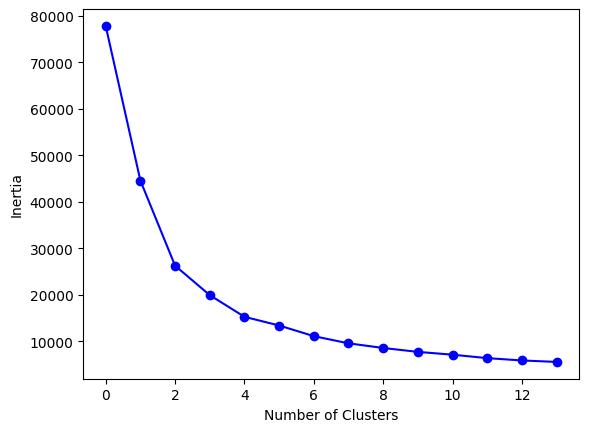

In [5]:
inertias = []
K = range(1,15)

for k in K :
    KMeans_model = KMeans(n_clusters = k , random_state = 42)
    KMeans_model.fit(pca_Train)
    inertias.append(KMeans_model.inertia_)
    
plt.plot(inertias , marker = 'o' , markersize = 6 , color = 'Blue')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()
   


## KMeans

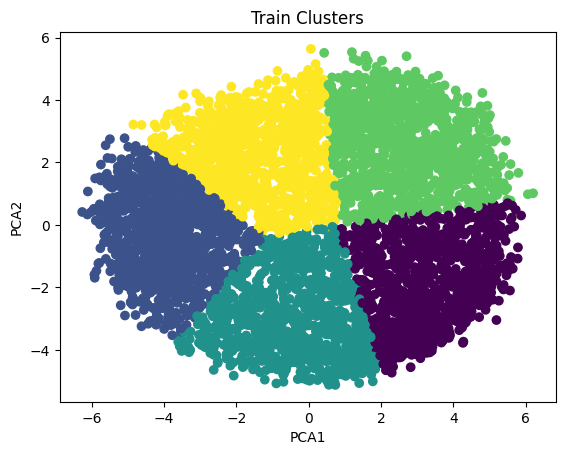

In [6]:
KMeans = KMeans(n_clusters = 5 , random_state = 42)
KMeans.fit(pca_Train)

train_Clusters = KMeans.predict(pca_Train)
Val_Clusters = KMeans.predict(pca_Val)
Test_Clusters = KMeans.predict(pca_Test)

plt.scatter(pca_Train['PC1'], pca_Train['PC2'], c = train_Clusters ,  cmap = 'viridis')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Train Clusters')
plt.show()


## DBScan

In [1]:
Db = DBSCAN(eps = 0.5 , min_samples = 50)
Db.fit(pca_Train)

Db_Train_Clusters = Db.fit_predict(pca_Train)
plt.scatter(pca_Train['PC1'], pca_Train['PC2'], c = Db_Train_Clusters ,  cmap = 'viridis')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('DBSCAN Clusters')
plt.show()


NameError: name 'DBSCAN' is not defined

## Gaussian Mixture Model (GMM)

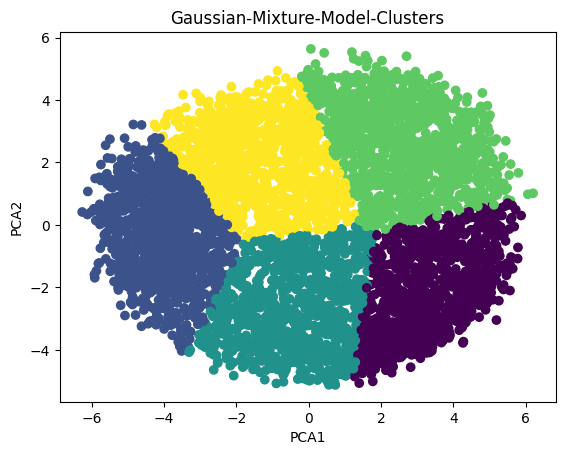

In [8]:
Gmm = GaussianMixture(n_components = 5 , random_state = 42)
Gmm.fit(pca_Train)

Gmm_Train_Cluster = Gmm.predict(pca_Train)
Gmm_Val_Cluster = Gmm.predict(pca_Val)
Gmm_Test_Cluster = Gmm.predict(pca_Test)

plt.scatter(pca_Train['PC1'], pca_Train['PC2'] , c = Gmm_Train_Cluster , cmap = 'viridis')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Gaussian-Mixture-Model-Clusters')
plt.show()


## New Dataset - Mnist with Anomalies

In [9]:
df_path1 =  'C:\\AI - Field\\Ds_Bootcamp\\Ds_4thweek\\mnist_with_anomalies.csv'
df1 = pd.read_csv(df_path1)
df1.head(10)



,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Import Libraries

 All Necessary Libraries Are Imported Above The Page

In [10]:
# Checking for Null Values in Datset 

df1.isnull().sum()

# Checking for Duplicated Values in Dataset

df1.duplicated().sum()
df1= df1.drop_duplicates()
df1.shape

# Train / Validation Split 
X1 = df1
X_train1,X_temp1 = train_test_split(X1, test_size=0.25, random_state=42)
X_val1,X_test1 =  train_test_split(X_temp1, test_size=0.5, random_state=42)


# Feature Scaling With MinMaxScaler

scaler1 = MinMaxScaler()

scaled_Train_df1 = scaler1.fit_transform(X_train1)
scaled_Train_df1 = pd.DataFrame(scaled_Train_df1, columns=X_train1.columns)

scaled_Val_df1 = scaler1.transform(X_val1)
scaled_Val_df1 = pd.DataFrame(scaled_Val_df1, columns=X_val1.columns)

scaled_Test_df1 = scaler1.transform(X_test1)
scaled_Test_df1 = pd.DataFrame(scaled_Test_df1, columns=X_test1.columns)


## Auto Encoder

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device being used: Cpu")

Device being used: Cpu


In [12]:
# Setting 2Dense Layer In AutoEncoder  

class AutoEncoder_model(nn.Module):
    def __init__(self):
        super(AutoEncoder_model, self).__init__()
        #Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 36),
            nn.ReLU(),
            nn.Linear(36, 18),
            nn.ReLU(),
            nn.Linear(18, 9)
        )
        #Decoder
        self.decoder = nn.Sequential(
            nn.Linear(9, 18),
            nn.ReLU(),
            nn.Linear(18, 36),
            nn.ReLU(),
            nn.Linear(36, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28)
        )
        #Implement The AutoEncoder On Variable "X"
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Model Training 

model = AutoEncoder_model().to(device)

Loss = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)





## Training Loop 

In [23]:
Epochs = 20
inputs_Train = torch.tensor(scaled_Train_df1.values, dtype=torch.float32).to(device)

for epoch in range(Epochs):

    model.train()

    optimizer.zero_grad()
    outputs = model(inputs)

    loss = Loss(outputs, inputs)
    loss.backward()

    optimizer.step()
    print("Epoch", epoch + 1, "/", Epochs, "loss =", loss.item())




Epoch 1 / 20 loss = 0.1154194101691246
Epoch 2 / 20 loss = 0.11535631120204926
Epoch 3 / 20 loss = 0.11528919637203217
Epoch 4 / 20 loss = 0.11521878838539124
Epoch 5 / 20 loss = 0.11515343934297562
Epoch 6 / 20 loss = 0.11508797109127045
Epoch 7 / 20 loss = 0.11502066999673843
Epoch 8 / 20 loss = 0.11495555192232132
Epoch 9 / 20 loss = 0.11489271372556686
Epoch 10 / 20 loss = 0.11483091115951538
Epoch 11 / 20 loss = 0.1147710382938385
Epoch 12 / 20 loss = 0.11471149325370789
Epoch 13 / 20 loss = 0.1146511435508728
Epoch 14 / 20 loss = 0.11459346860647202
Epoch 15 / 20 loss = 0.11453665047883987
Epoch 16 / 20 loss = 0.11447986960411072
Epoch 17 / 20 loss = 0.11442357301712036
Epoch 18 / 20 loss = 0.11436663568019867
Epoch 19 / 20 loss = 0.11431025713682175
Epoch 20 / 20 loss = 0.11425483226776123


## Validation Loop

In [25]:
inputs_Val = torch.tensor(scaled_Val_df1.values, dtype=torch.float32).to(device)


model.eval()

with torch.no_grad():

    outputs_val = model(inputs_Val)
    val_loss = Loss(outputs_val, inputs_Val)
    print("Validation Loss =", val_loss.item())



Validation Loss = 0.11420301347970963


In [26]:
inputs_Test = torch.tensor(scaled_Test_df1.values, dtype=torch.float32).to(device)


model.eval()

with torch.no_grad():

    outputs_Test = model(inputs_Test)
    Test_loss = Loss(outputs_Test, inputs_Test)
    print("Validation Loss =", Test_loss.item())



Validation Loss = 0.2277061492204666


## Model Evaluation

In [27]:
model.eval()

train_losses = []
test_losses = []
recon_errors = []

with torch.no_grad():

        # ---- TRAIN EVALUATION ----
    train_outputs = model(inputs_Train)
    train_loss = Loss(train_outputs, inputs_Train)
    train_losses.append(train_loss.item())

    # reconstruction error per sample (important for analysis)
    train_error = torch.mean((train_outputs - inputs_Train) ** 2, dim=1)
    
    # ---- TEST EVALUATION ----
    test_outputs = model(inputs_Test)
    test_loss = Loss(test_outputs, inputs_Test)
    test_losses.append(test_loss.item())

    test_error = torch.mean((test_outputs - inputs_Test) ** 2, dim=1)
    recon_errors.append(test_error)

    # ---- SUMMARY ----
    print("Train Loss:", train_loss.item())
    print("Test Loss:", test_loss.item())

Train Loss: 0.05918807536363602
Test Loss: 0.2277061492204666


## Compute reconstruction error

In [29]:
model.eval()

with torch.no_grad():
    recons = model(inputs_Test)
    errors = torch.mean((recons - inputs_Test)**2 , dim = 1)



Threshold = torch.quantile(errors , 0.95)
Anomalies = errors > Threshold


## Visualization Chapter

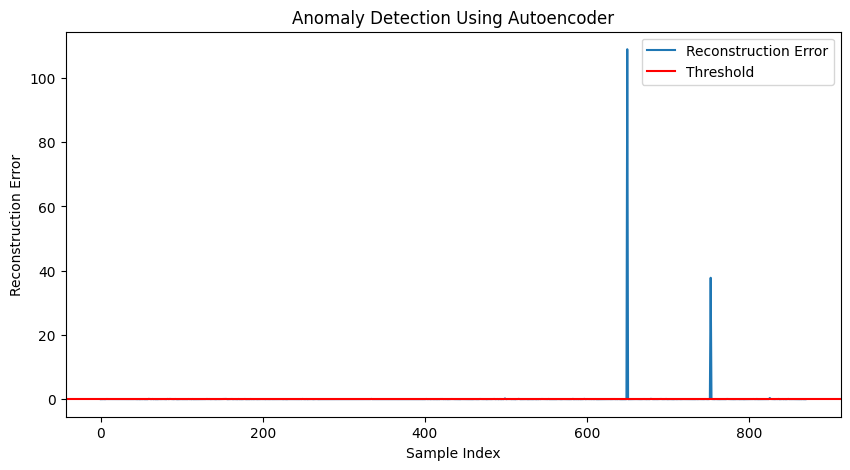

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(errors.cpu().numpy(), label="Reconstruction Error")
plt.axhline(Threshold.item(), color='red', linestyle='-', label="Threshold")

plt.title("Anomaly Detection Using Autoencoder")
plt.xlabel("Sample Index")
plt.ylabel("Reconstruction Error")

plt.legend()
plt.show()

## Anomaly Detection Result 

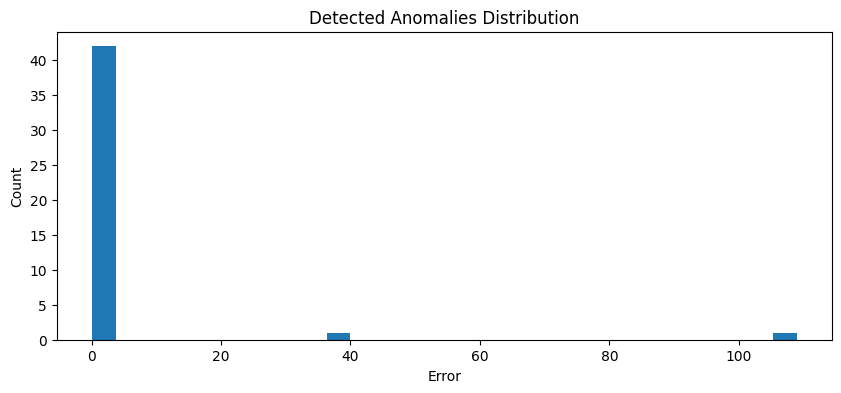

In [35]:
anomaly_values = errors[Anomalies]

plt.figure(figsize=(10, 4))
plt.hist(anomaly_values.cpu().numpy(), bins=30)


plt.title("Detected Anomalies Distribution")
plt.xlabel("Error")
plt.ylabel("Count")


plt.show()

Industry Code Style Wich Is Generated By CHAT-GPT

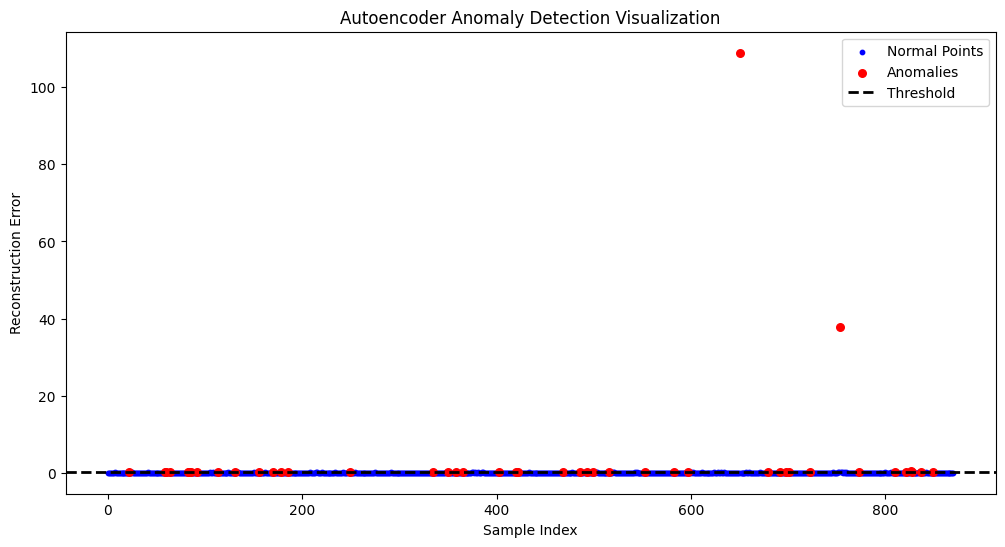

In [ ]:
model.eval()

with torch.no_grad():
    recon = model(inputs_Test)
    errors = torch.mean((recon - inputs_Test) ** 2, dim=1)

# threshold (95% rule)
threshold = torch.quantile(errors, 0.95)

anomalies = errors > threshold

errors_np = errors.cpu().numpy()
anomalies_np = anomalies.cpu().numpy()

plt.figure(figsize=(12, 6))

# all points
plt.scatter(
    np.arange(len(errors_np)),
    errors_np,
    c="blue",
    s=10,
    label="Normal Points"
)

# anomalies highlighted
plt.scatter(
    np.arange(len(errors_np))[anomalies_np],
    errors_np[anomalies_np],
    c="red",
    s=30,
    label="Anomalies"
)

# threshold line
plt.axhline(
    threshold.item(),
    color="black",
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.title("Autoencoder Anomaly Detection Visualization")
plt.xlabel("Sample Index")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.show()